In [ ]:
import torch
print(torch.cuda.is_available())      # doit afficher True
print(torch.cuda.get_device_name(0))  # doit afficher Tesla T4

In [ ]:
import torch

# ── Vérification du matériel ─────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device utilisé : {device.type.upper()}')

if device.type == 'cuda':
    # Si un GPU est trouvé, on affiche son nom et sa mémoire
    gpu_name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'Modèle du GPU  : {gpu_name}')
    print(f'VRAM totale    : {vram:.1f} GB')
    print('✅ Tout est prêt pour un entraînement ultra-rapide !')
else:
    print('⚠️ ALERTE : Aucun GPU détecté. L\'entraînement se fera sur CPU (très lent).')

## Dataloaders

In [ ]:
import os
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from PIL import Image

# ── Chemins Kaggle ────────────────────────────────────────────────────────────
CSV_DATASET_NAME = 'datasets/oussamaaitmohamed/dataset-melanoma-cleaned'
CSV_DIR          = f'/kaggle/input/{CSV_DATASET_NAME}'
TRAIN_CSV        = os.path.join(CSV_DIR, 'tabular_train.csv')
VAL_CSV          = os.path.join(CSV_DIR, 'tabular_val.csv')
MODELS_DIR       = '/kaggle/working/models'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Lecture des CSV ───────────────────────────────────────────────────────────
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)

# ── Correction des chemins ────────────────────────────────────────────────────
BASE_IMAGE_DIR = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'

train_df['path'] = train_df['path'].str.replace('\\', '/', regex=False)
val_df['path']   = val_df['path'].str.replace('\\', '/', regex=False)

train_df['path'] = train_df['path'].str.replace('../data/raw', BASE_IMAGE_DIR, regex=False)
val_df['path']   = val_df['path'].str.replace('../data/raw', BASE_IMAGE_DIR, regex=False)

train_df['path'] = train_df['path'].str.replace(
    r'HAM10000_images_part(\d)', r'HAM10000_images_part_\1', regex=True)
val_df['path']   = val_df['path'].str.replace(
    r'HAM10000_images_part(\d)', r'HAM10000_images_part_\1', regex=True)

# Vérification
for path in train_df['path'].head(3):
    print(f"{'✅' if os.path.exists(path) else '❌'} {path}")
print(f'Train : {len(train_df)} images | Val : {len(val_df)} images')

# ── Transformations LÉGÈRES (version gagnante) ────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize(232),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize(232),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Dataset ───────────────────────────────────────────────────────────────────
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None, label_map=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_map = label_map

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path  = self.dataframe.loc[idx, 'path']
        label_str = self.dataframe.loc[idx, 'dx']
        image     = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(self.label_map[label_str], dtype=torch.long)
        return image, label

# ── Label map ─────────────────────────────────────────────────────────────────
classes     = sorted(train_df['dx'].unique())
label_map   = {cls: idx for idx, cls in enumerate(classes)}
NUM_CLASSES = len(classes)
print(f'Classes ({NUM_CLASSES}) : {label_map}')

# ── WeightedRandomSampler ─────────────────────────────────────────────────────
class_counts   = train_df['dx'].value_counts().to_dict()
sample_weights = [1.0 / class_counts[label] for label in train_df['dx']]
sampler        = WeightedRandomSampler(
    weights     = torch.DoubleTensor(sample_weights),
    num_samples = len(sample_weights),
    replacement = True
)

# ── DataLoaders ───────────────────────────────────────────────────────────────
BATCH_SIZE  = 32
NUM_WORKERS = 2

train_dataset = HAM10000Dataset(train_df, transform=train_transforms, label_map=label_map)
val_dataset   = HAM10000Dataset(val_df,   transform=val_transforms,   label_map=label_map)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'\nBatches train : {len(train_loader)} | Batches val : {len(val_loader)}')

## Architecture CustomCNN

In [ ]:
import torch.nn as nn

class CustomCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(CustomCNN, self).__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

        # 4 blocs — version gagnante
        self.block1 = conv_block(3,    32)   # [3,224,224]  → [32,112,112]
        self.block2 = conv_block(32,   64)   # [32,112,112] → [64,56,56]
        self.block3 = conv_block(64,  128)   # [64,56,56]   → [128,28,28]
        self.block4 = conv_block(128, 256)   # [128,28,28]  → [256,14,14]

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier simple — version gagnante
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

# ── Instanciation ──────────────────────────────────────────────────────────────
model = CustomCNN(num_classes=NUM_CLASSES).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Paramètres totaux     : {total_params:,}')
print(f'Paramètres entraîn.   : {trainable_params:,}')
print(f'Modèle sur            : {next(model.parameters()).device}')

dummy = torch.randn(2, 3, 224, 224).to(device)
out   = model(dummy)
print(f'\nTest forward pass OK → sortie shape : {out.shape}')
print('✅ Architecture CustomCNN OK.')

### Loss, Optimiseur & Scheduler

In [ ]:
import torch.optim as optim

# Loss standard — sans label_smoothing
criterion = nn.CrossEntropyLoss()

# Optimiseur
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print(f'\nLoss        : CrossEntropyLoss (standard)')
print(f'Optimiseur  : Adam  (lr=1e-3, weight_decay=1e-4)')
print(f'Scheduler   : ReduceLROnPlateau (factor=0.5, patience=3)')
print('✅ Loss, optimiseur et scheduler configurés.')

### Fonctions train_step et val_step

In [ ]:
def train_step(model, dataloader, criterion, optimizer, device):
    """
    Un passage complet sur le dataset d'entraînement.
    Retourne la loss moyenne sur l'époque.
    """
    model.train()   # Active Dropout + BatchNorm en mode entraînement
    running_loss = 0.0
    n_batches    = len(dataloader)

    for batch_idx, (inputs, labels) in enumerate(dataloader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()           # 1. Réinitialise les gradients
        outputs = model(inputs)         # 2. Forward pass
        loss    = criterion(outputs, labels)  # 3. Calcul de la loss
        loss.backward()                 # 4. Backpropagation
        optimizer.step()                # 5. Mise à jour des poids

        running_loss += loss.item()

        # Affichage de la progression tous les 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f'    Batch {batch_idx+1}/{n_batches} — loss batch : {loss.item():.4f}')

    # Loss moyenne = somme des losses / nombre de batches
    epoch_loss = running_loss / n_batches
    return epoch_loss


def val_step(model, dataloader, criterion, device):
    """
    Évaluation sur le dataset de validation (sans mise à jour des poids).
    Retourne la loss moyenne et l'accuracy.
    """
    model.eval()    # Désactive Dropout + met BatchNorm en mode évaluation
    running_loss        = 0.0
    correct_predictions = 0
    total_predictions   = 0
    n_batches           = len(dataloader)

    with torch.no_grad():   # Désactive le graphe de calcul → moins de RAM
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            running_loss += loss.item()

            # Classe prédite = index du logit maximal
            _, predicted = torch.max(outputs, dim=1)
            total_predictions   += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / n_batches
    epoch_acc  = correct_predictions / total_predictions * 100
    return epoch_loss, epoch_acc


print('✅ Fonctions train_step et val_step prêtes.')

### Boucle d'entraînement principale

**Durée estimée sur Colab GPU T4 :** ~3 à 5 min par époque → ~25 à 40 min pour 10 époques.

In [ ]:
import time

NUM_EPOCHS     = 30
EARLY_STOP_PAT = 7
SAVE_PATH      = os.path.join(MODELS_DIR, 'custom_cnn_best.pth')

history           = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_loss     = float('inf')
epochs_no_improve = 0

print(f'Entraînement sur {NUM_EPOCHS} époques — device : {device}')
print(f'Batches/époque : train={len(train_loader)} | val={len(val_loader)}')
print('=' * 65)

for epoch in range(NUM_EPOCHS):
    start_time = time.time()
    print(f'\n--- Époque {epoch+1}/{NUM_EPOCHS} ---')

    train_loss            = train_step(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc     = val_step(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    duration = time.time() - start_time
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), SAVE_PATH)
        save_msg = '🌟 Meilleur modèle sauvegardé !'
    else:
        epochs_no_improve += 1
        save_msg = f'(pas d\'amélioration — {epochs_no_improve}/{EARLY_STOP_PAT})'

    lr_actuel = optimizer.param_groups[0]['lr']
    print(f'Train Loss : {train_loss:.4f} | Val Loss : {val_loss:.4f} | Val Acc : {val_acc:.2f}%')
    print(f'LR actuel  : {lr_actuel:.2e} | Durée : {duration:.0f}s | {save_msg}')

    if epochs_no_improve >= EARLY_STOP_PAT:
        print(f'\n⏹  Early stopping : pas d\'amélioration depuis {EARLY_STOP_PAT} époques.')
        break

print('\n' + '=' * 65)
print(f'✅ Entraînement terminé !')
print(f'   Meilleure Val Loss : {best_val_loss:.4f}')
print(f'   Modèle sauvegardé  : {SAVE_PATH}')

### Resultats de la boucle d'entrainement

Entraînement sur 30 époques — device : cuda
Batches/époque : train=250 | val=33
=================================================================

--- Époque 1/30 ---
    Batch 50/250 — loss batch : 1.7610
    Batch 100/250 — loss batch : 1.6164
    Batch 150/250 — loss batch : 1.4867
    Batch 200/250 — loss batch : 1.8528
    Batch 250/250 — loss batch : 1.3586
Train Loss : 1.6659 | Val Loss : 1.3293 | Val Acc : 46.83%
LR actuel  : 1.00e-03 | Durée : 87s | 🌟 Meilleur modèle sauvegardé !

--- Époque 2/30 ---
    Batch 50/250 — loss batch : 1.4466
    Batch 100/250 — loss batch : 1.5481
    Batch 150/250 — loss batch : 1.4665
    Batch 200/250 — loss batch : 1.3151
    Batch 250/250 — loss batch : 1.3753
Train Loss : 1.4884 | Val Loss : 1.1551 | Val Acc : 55.61%
LR actuel  : 1.00e-03 | Durée : 76s | 🌟 Meilleur modèle sauvegardé !

--- Époque 3/30 ---
    Batch 50/250 — loss batch : 1.4680
    Batch 100/250 — loss batch : 1.4513
    Batch 150/250 — loss batch : 1.4191
    Batch 200/250 — loss batch : 1.2252
    Batch 250/250 — loss batch : 1.3242
Train Loss : 1.4468 | Val Loss : 1.2720 | Val Acc : 50.63%
LR actuel  : 1.00e-03 | Durée : 73s | (pas d'amélioration — 1/7)

--- Époque 4/30 ---
    Batch 50/250 — loss batch : 1.4266
    Batch 100/250 — loss batch : 1.5513
    Batch 150/250 — loss batch : 1.3841
    Batch 200/250 — loss batch : 1.2938
    Batch 250/250 — loss batch : 1.1525
Train Loss : 1.3947 | Val Loss : 1.3077 | Val Acc : 48.98%
LR actuel  : 1.00e-03 | Durée : 72s | (pas d'amélioration — 2/7)

--- Époque 5/30 ---
    Batch 50/250 — loss batch : 1.4220
    Batch 100/250 — loss batch : 1.4695
    Batch 150/250 — loss batch : 1.2492
    Batch 200/250 — loss batch : 1.3988
    Batch 250/250 — loss batch : 1.6205
Train Loss : 1.3746 | Val Loss : 1.1719 | Val Acc : 54.05%
LR actuel  : 1.00e-03 | Durée : 71s | (pas d'amélioration — 3/7)

--- Époque 6/30 ---
    Batch 50/250 — loss batch : 1.2536
    Batch 100/250 — loss batch : 1.2363
    Batch 150/250 — loss batch : 1.3998
    Batch 200/250 — loss batch : 1.2567
    Batch 250/250 — loss batch : 1.5245
Train Loss : 1.3234 | Val Loss : 1.2258 | Val Acc : 52.00%
LR actuel  : 5.00e-04 | Durée : 71s | (pas d'amélioration — 4/7)

--- Époque 7/30 ---
    Batch 50/250 — loss batch : 1.3519
    Batch 100/250 — loss batch : 1.2191
    Batch 150/250 — loss batch : 1.2473
    Batch 200/250 — loss batch : 1.3251
    Batch 250/250 — loss batch : 1.3546
Train Loss : 1.2640 | Val Loss : 1.1237 | Val Acc : 55.02%
LR actuel  : 5.00e-04 | Durée : 71s | 🌟 Meilleur modèle sauvegardé !

--- Époque 8/30 ---
    Batch 50/250 — loss batch : 1.3352
    Batch 100/250 — loss batch : 1.4296
    Batch 150/250 — loss batch : 1.1584
    Batch 200/250 — loss batch : 1.2936
    Batch 250/250 — loss batch : 1.2642
Train Loss : 1.2349 | Val Loss : 1.1669 | Val Acc : 54.73%
LR actuel  : 5.00e-04 | Durée : 71s | (pas d'amélioration — 1/7)

--- Époque 9/30 ---
    Batch 50/250 — loss batch : 1.2362
    Batch 100/250 — loss batch : 1.0159
    Batch 150/250 — loss batch : 1.2639
    Batch 200/250 — loss batch : 1.0492
    Batch 250/250 — loss batch : 1.2703
Train Loss : 1.1834 | Val Loss : 1.3622 | Val Acc : 49.27%
LR actuel  : 5.00e-04 | Durée : 71s | (pas d'amélioration — 2/7)

--- Époque 10/30 ---
    Batch 50/250 — loss batch : 1.2214
    Batch 100/250 — loss batch : 1.1698
    Batch 150/250 — loss batch : 1.3420
    Batch 200/250 — loss batch : 1.0724
    Batch 250/250 — loss batch : 0.9889
Train Loss : 1.1846 | Val Loss : 1.2123 | Val Acc : 52.39%
LR actuel  : 5.00e-04 | Durée : 71s | (pas d'amélioration — 3/7)

--- Époque 11/30 ---
    Batch 50/250 — loss batch : 1.3195
    Batch 100/250 — loss batch : 1.0637
    Batch 150/250 — loss batch : 1.3881
    Batch 200/250 — loss batch : 1.1197
    Batch 250/250 — loss batch : 1.3068
Train Loss : 1.1747 | Val Loss : 1.1634 | Val Acc : 54.73%
LR actuel  : 2.50e-04 | Durée : 69s | (pas d'amélioration — 4/7)

--- Époque 12/30 ---
    Batch 50/250 — loss batch : 1.3482
    Batch 100/250 — loss batch : 1.1338
    Batch 150/250 — loss batch : 1.0875
    Batch 200/250 — loss batch : 1.4894
    Batch 250/250 — loss batch : 1.0427
Train Loss : 1.1112 | Val Loss : 1.0681 | Val Acc : 55.61%
LR actuel  : 2.50e-04 | Durée : 71s | 🌟 Meilleur modèle sauvegardé !

--- Époque 13/30 ---
    Batch 50/250 — loss batch : 0.9787
    Batch 100/250 — loss batch : 0.8102
    Batch 150/250 — loss batch : 1.3291
    Batch 200/250 — loss batch : 1.3424
    Batch 250/250 — loss batch : 1.0997
Train Loss : 1.1059 | Val Loss : 1.1646 | Val Acc : 53.95%
LR actuel  : 2.50e-04 | Durée : 71s | (pas d'amélioration — 1/7)

--- Époque 14/30 ---
    Batch 50/250 — loss batch : 0.8329
    Batch 100/250 — loss batch : 1.0053
    Batch 150/250 — loss batch : 0.8538
    Batch 200/250 — loss batch : 1.2173
    Batch 250/250 — loss batch : 1.4444
Train Loss : 1.0991 | Val Loss : 1.1310 | Val Acc : 54.93%
LR actuel  : 2.50e-04 | Durée : 71s | (pas d'amélioration — 2/7)

--- Époque 15/30 ---
    Batch 50/250 — loss batch : 0.9922
    Batch 100/250 — loss batch : 1.0412
    Batch 150/250 — loss batch : 1.3049
    Batch 200/250 — loss batch : 1.1000
    Batch 250/250 — loss batch : 1.6749
Train Loss : 1.0930 | Val Loss : 1.0569 | Val Acc : 57.27%
LR actuel  : 2.50e-04 | Durée : 72s | 🌟 Meilleur modèle sauvegardé !

--- Époque 16/30 ---
    Batch 50/250 — loss batch : 0.9981
    Batch 100/250 — loss batch : 1.1329
    Batch 150/250 — loss batch : 0.9693
    Batch 200/250 — loss batch : 1.0060
    Batch 250/250 — loss batch : 1.2300
Train Loss : 1.0632 | Val Loss : 1.0814 | Val Acc : 55.22%
LR actuel  : 2.50e-04 | Durée : 71s | (pas d'amélioration — 1/7)

--- Époque 17/30 ---
    Batch 50/250 — loss batch : 1.0526
    Batch 100/250 — loss batch : 0.7278
    Batch 150/250 — loss batch : 0.9773
    Batch 200/250 — loss batch : 1.0915
    Batch 250/250 — loss batch : 1.4254
Train Loss : 1.0747 | Val Loss : 1.0776 | Val Acc : 56.20%
LR actuel  : 2.50e-04 | Durée : 71s | (pas d'amélioration — 2/7)

--- Époque 18/30 ---
    Batch 50/250 — loss batch : 0.7287
    Batch 100/250 — loss batch : 1.1222
    Batch 150/250 — loss batch : 1.0969
    Batch 200/250 — loss batch : 1.2959
    Batch 250/250 — loss batch : 0.8177
Train Loss : 1.0796 | Val Loss : 1.1719 | Val Acc : 54.15%
LR actuel  : 2.50e-04 | Durée : 71s | (pas d'amélioration — 3/7)

--- Époque 19/30 ---
    Batch 50/250 — loss batch : 0.7979
    Batch 100/250 — loss batch : 1.2317
    Batch 150/250 — loss batch : 0.9749
    Batch 200/250 — loss batch : 0.8672
    Batch 250/250 — loss batch : 1.2401
Train Loss : 1.0401 | Val Loss : 1.0276 | Val Acc : 58.73%
LR actuel  : 2.50e-04 | Durée : 70s | 🌟 Meilleur modèle sauvegardé !

--- Époque 20/30 ---
    Batch 50/250 — loss batch : 0.9267
    Batch 100/250 — loss batch : 0.9591
    Batch 150/250 — loss batch : 0.8329
    Batch 200/250 — loss batch : 0.7900
    Batch 250/250 — loss batch : 0.7884
Train Loss : 1.0498 | Val Loss : 1.1038 | Val Acc : 54.54%
LR actuel  : 2.50e-04 | Durée : 70s | (pas d'amélioration — 1/7)

--- Époque 21/30 ---
    Batch 50/250 — loss batch : 1.0025
    Batch 100/250 — loss batch : 0.9355
    Batch 150/250 — loss batch : 1.1834
    Batch 200/250 — loss batch : 0.9544
    Batch 250/250 — loss batch : 1.1690
Train Loss : 1.0495 | Val Loss : 1.1415 | Val Acc : 55.02%
LR actuel  : 2.50e-04 | Durée : 71s | (pas d'amélioration — 2/7)

--- Époque 22/30 ---
    Batch 50/250 — loss batch : 0.9843
    Batch 100/250 — loss batch : 0.8619
    Batch 150/250 — loss batch : 1.2260
    Batch 200/250 — loss batch : 0.8314
    Batch 250/250 — loss batch : 1.4022
Train Loss : 1.0384 | Val Loss : 1.1901 | Val Acc : 54.34%
LR actuel  : 2.50e-04 | Durée : 71s | (pas d'amélioration — 3/7)

--- Époque 23/30 ---
    Batch 50/250 — loss batch : 1.0705
    Batch 100/250 — loss batch : 1.0964
    Batch 150/250 — loss batch : 1.1882
    Batch 200/250 — loss batch : 1.1856
    Batch 250/250 — loss batch : 1.1225
Train Loss : 1.0195 | Val Loss : 1.0490 | Val Acc : 58.15%
LR actuel  : 1.25e-04 | Durée : 71s | (pas d'amélioration — 4/7)

--- Époque 24/30 ---
    Batch 50/250 — loss batch : 0.9716
    Batch 100/250 — loss batch : 1.0450
    Batch 150/250 — loss batch : 1.0029
    Batch 200/250 — loss batch : 0.8629
    Batch 250/250 — loss batch : 1.0171
Train Loss : 1.0210 | Val Loss : 1.0489 | Val Acc : 58.24%
LR actuel  : 1.25e-04 | Durée : 72s | (pas d'amélioration — 5/7)

--- Époque 25/30 ---
    Batch 50/250 — loss batch : 1.0736
    Batch 100/250 — loss batch : 0.8940
    Batch 150/250 — loss batch : 1.0367
    Batch 200/250 — loss batch : 1.0014
    Batch 250/250 — loss batch : 1.5916
Train Loss : 0.9917 | Val Loss : 1.0933 | Val Acc : 55.90%
LR actuel  : 1.25e-04 | Durée : 70s | (pas d'amélioration — 6/7)

--- Époque 26/30 ---
    Batch 50/250 — loss batch : 1.0961
    Batch 100/250 — loss batch : 1.1152
    Batch 150/250 — loss batch : 0.9053
    Batch 200/250 — loss batch : 0.8883
    Batch 250/250 — loss batch : 1.2251
Train Loss : 0.9912 | Val Loss : 1.0499 | Val Acc : 56.10%
LR actuel  : 1.25e-04 | Durée : 70s | (pas d'amélioration — 7/7)

⏹  Early stopping : pas d'amélioration depuis 7 époques.

=================================================================
✅ Entraînement terminé !
   Meilleure Val Loss : 1.0276
   Modèle sauvegardé  : /kaggle/working/models/custom_cnn_best.pth

===================================

3. Comment savoir si le modèle s'entraîne bien ou s'il fait du surapprentissage ?
Pendant que la boucle va tourner sur Google Colab, vous allez voir les scores s'afficher (Train Loss, Val Loss, Val Acc). Voici comment interpréter ces chiffres comme un véritable ingénieur IA :

✅ Scénario 1 : L'Apprentissage Sain (Tout va bien)

La Train Loss diminue doucement.

La Val Loss diminue en même temps (ou reste très proche).

La Val Accuracy monte progressivement.

Diagnostic : Le modèle apprend les vraies règles de la dermatologie et arrive à les appliquer sur de nouveaux patients.

🚨 Scénario 2 : Le Surapprentissage (Overfitting)

La Train Loss continue de baisser fortement (elle s'approche de 0).

La Val Loss arrête de baisser, stagne, puis commence à remonter.

La Val Accuracy stagne.

Diagnostic : C'est le piège classique. Le modèle a un "cerveau" trop grand ou s'est entraîné trop longtemps. Au lieu d'apprendre à reconnaître un mélanome de manière générale, il a littéralement photographié et appris par cœur les 8000 images d'entraînement. Dès qu'on lui montre une image de validation (qu'il n'a pas apprise par cœur), il panique et se trompe. (L'Early Stopping est justement là pour couper le programme dès que ce scénario commence !).

⚠️ Scénario 3 : Le Sous-apprentissage (Underfitting)

La Train Loss refuse de baisser et reste très haute.

La Val Accuracy reste bloquée autour de 10% ou 20%.

Diagnostic : Soit le taux d'apprentissage (Learning Rate) est mauvais, soit le modèle est trop petit, soit il y a un bug dans les données. Le modèle n'arrive même pas à comprendre l'entraînement.

### Courbes d'entraînement

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Courbes d\'entraînement — CustomCNN from scratch', fontsize=13, fontweight='bold')

# ── Loss ────────────────────────────────────────────────────────────────────
axes[0].plot(epochs_range, history['train_loss'], 'o-', color='#5B9BD5', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   's-', color='#E05252', label='Val Loss')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss par époque')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Accuracy ─────────────────────────────────────────────────────────────────
axes[1].plot(epochs_range, history['val_acc'], 's-', color='#5BAD72', label='Val Accuracy')
axes[1].axhline(y=75, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy de validation par époque')
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# ── Sauvegarde ───────────────────────────────────────────────────────────────
# On utilise /kaggle/working pour avoir le droit d'écrire le fichier
REPORTS_DIR = '/kaggle/working/reports/figures'
curves_path = os.path.join(REPORTS_DIR, 'training_curves_cnn_scratch.png')

os.makedirs(REPORTS_DIR, exist_ok=True)
plt.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Courbes sauvegardées : {curves_path}')

# ── Diagnostic rapide ────────────────────────────────────────────────────────
final_train = history['train_loss'][-1]
final_val   = history['val_loss'][-1]
final_acc   = history['val_acc'][-1]
gap         = final_val - final_train

print(f'\n── Diagnostic ────────────────────────────────────────────────────')
print(f'Val Accuracy finale   : {final_acc:.2f}%')
print(f'Écart Train/Val Loss  : {gap:.4f}')
if gap > 0.5:
    print('⚠️  Écart élevé → probable overfitting. Augmenter le Dropout ou l\'augmentation.')
elif final_acc < 50:
    print('⚠️  Accuracy faible → underfitting. Augmenter NUM_EPOCHS ou la capacité du modèle.')
else:
    print('✅ Entraînement semble stable. Passer à la Phase 03B (EfficientNetB0).')

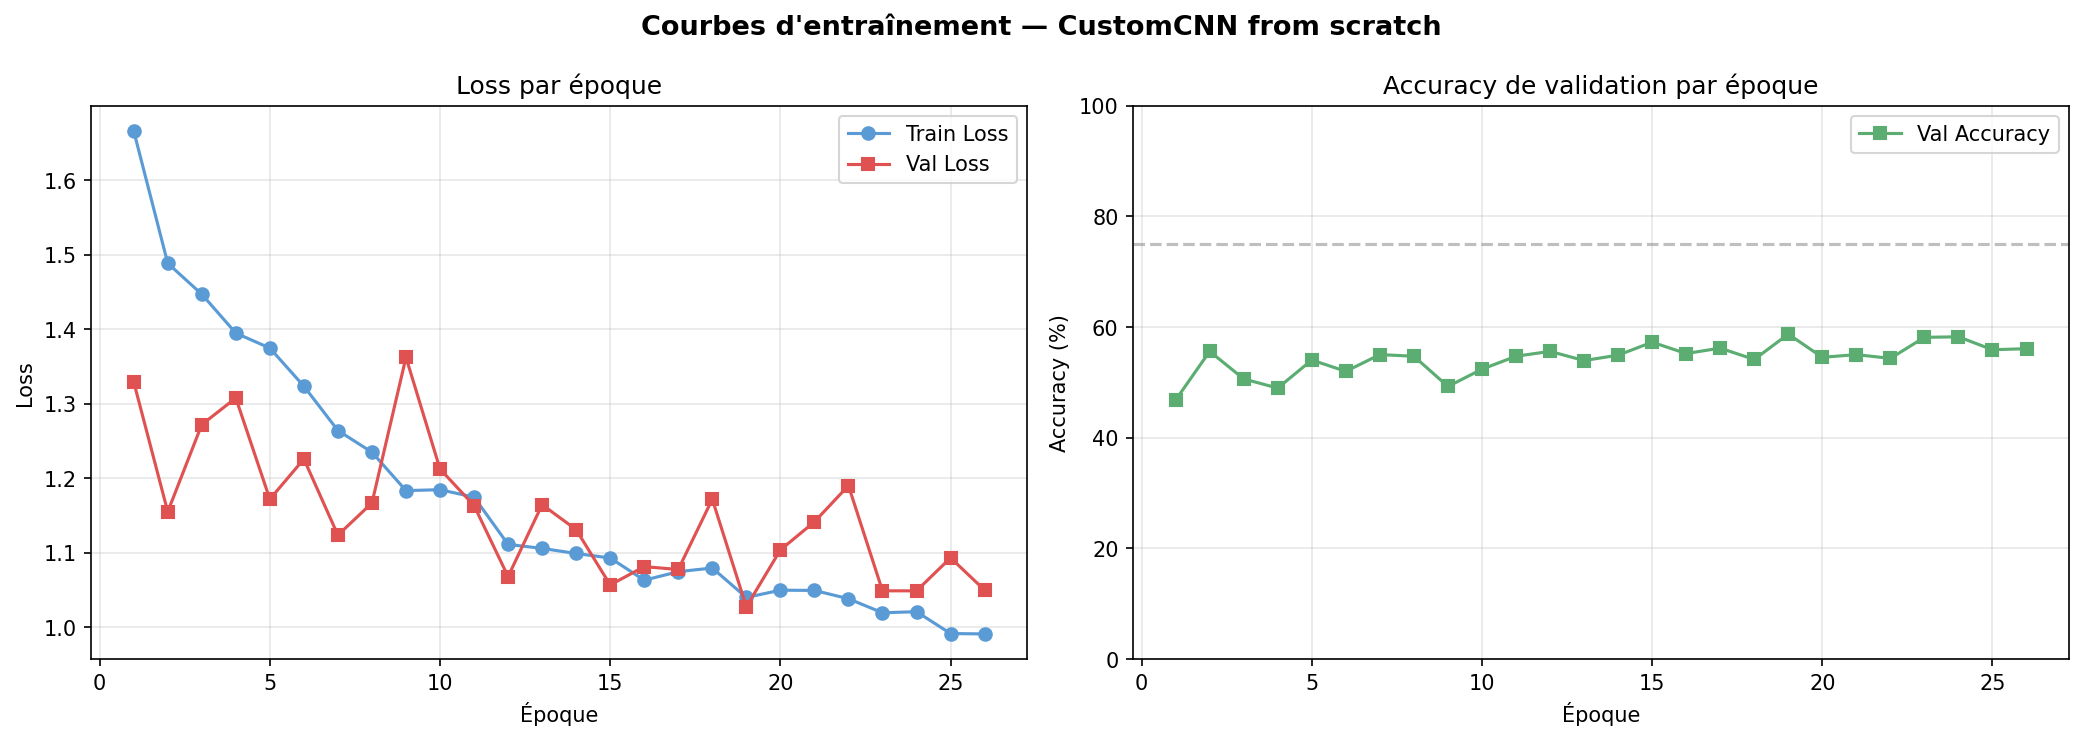

L’analyse des courbes met en évidence plusieurs éléments importants. Du côté de la loss, la courbe d’entraînement diminue de façon régulière et stable, ce qui indique que le modèle apprend correctement et que l’optimisation se déroule sans problème. En revanche, la loss de validation présente des fluctuations en zigzag, un comportement classique souvent lié à une taille plus réduite du jeu de validation. On observe également qu’après un certain nombre d’époques, cette courbe cesse réellement de s’améliorer, ce qui justifie l’utilisation de l’early stopping pour éviter un surapprentissage inutile. Concernant l’accuracy, la courbe montre une progression rapide au début, puis atteint un palier autour de 55 à 60 %, avec de légères oscillations mais sans amélioration notable par la suite. Cette stagnation suggère que le modèle atteint rapidement ses limites : le problème ne semble pas venir d’une erreur d’implémentation, mais plutôt d’une capacité insuffisante du réseau, probablement trop simple pour capturer des différences fines entre les classes.

### Courbes de test

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# ── 1. Configuration et Préparation du Test Set ──────────────────────────────
TEST_CSV = os.path.join(CSV_DIR, 'tabular_test.csv')
MODEL_PATH = '/kaggle/working/models/custom_cnn_best.pth'

# Lecture et correction stricte des chemins (comme pour le train/val)
test_df = pd.read_csv(TEST_CSV)
test_df['path'] = test_df['path'].str.replace('\\', '/')
test_df['path'] = test_df['path'].str.replace('../data/raw', BASE_IMAGE_DIR)
test_df['path'] = test_df['path'].str.replace('part1', 'part_1').str.replace('part2', 'part_2')

print(f'Déverrouillage du Test Set : {len(test_df)} images prêtes pour l\'examen.')

# ── 2. DataLoader Spécifique pour l'Inférence ───────────────────────────────
# ATTENTION : On utilise val_transforms (aucune triche/augmentation)
test_dataset = HAM10000Dataset(test_df, transform=val_transforms, label_map=label_map)

# SHUFFLE=FALSE est absolument obligatoire ici. 
# Si on mélange, on ne saura plus quelle prédiction correspond à quelle image !
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# ── 3. Chargement du Cerveau (Poids du Modèle) ──────────────────────────────
# On charge les poids du meilleur modèle sauvegardé
model.load_state_dict(torch.load(MODEL_PATH))
model = model.to(device)

# model.eval() désactive le Dropout. Le modèle utilise 100% de ses neurones.
model.eval() 

# ── 4. Boucle d'Évaluation (Inférence) ──────────────────────────────────────
y_true = []
y_pred = []

print("\nLancement des prédictions sur le GPU...")

# torch.no_grad() coupe le moteur d'apprentissage. 
# On ne calcule plus les gradients, ce qui rend la prédiction ultra-rapide.
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        
        # On prend l'indice de la probabilité la plus haute
        _, predicted = torch.max(outputs, 1)
        
        # On stocke la réalité et la prédiction dans nos listes
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("✅ Inférence terminée avec succès !")

# ── 5. Visualisation : Matrice de Confusion ─────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes,
            linewidths=1, linecolor='black')
plt.ylabel('Véritable Maladie (Diagnostic Médecin)', fontweight='bold')
plt.xlabel('Prédiction du Modèle (IA)', fontweight='bold')
plt.title('Matrice de Confusion — Examen Final (Test Set)', fontsize=14, fontweight='bold')

# Sauvegarde pour la présentation
cm_path = '/kaggle/working/reports/figures/confusion_matrix_test.png'
os.makedirs(os.path.dirname(cm_path), exist_ok=True)
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()

# ── 6. Rapport de Classification (Les vraies métriques) ─────────────────────
print("\n" + "="*50)
print("RAPPORT DE CLASSIFICATION OFFICIEL")
print("="*50)
print(classification_report(y_true, y_pred, target_names=classes))

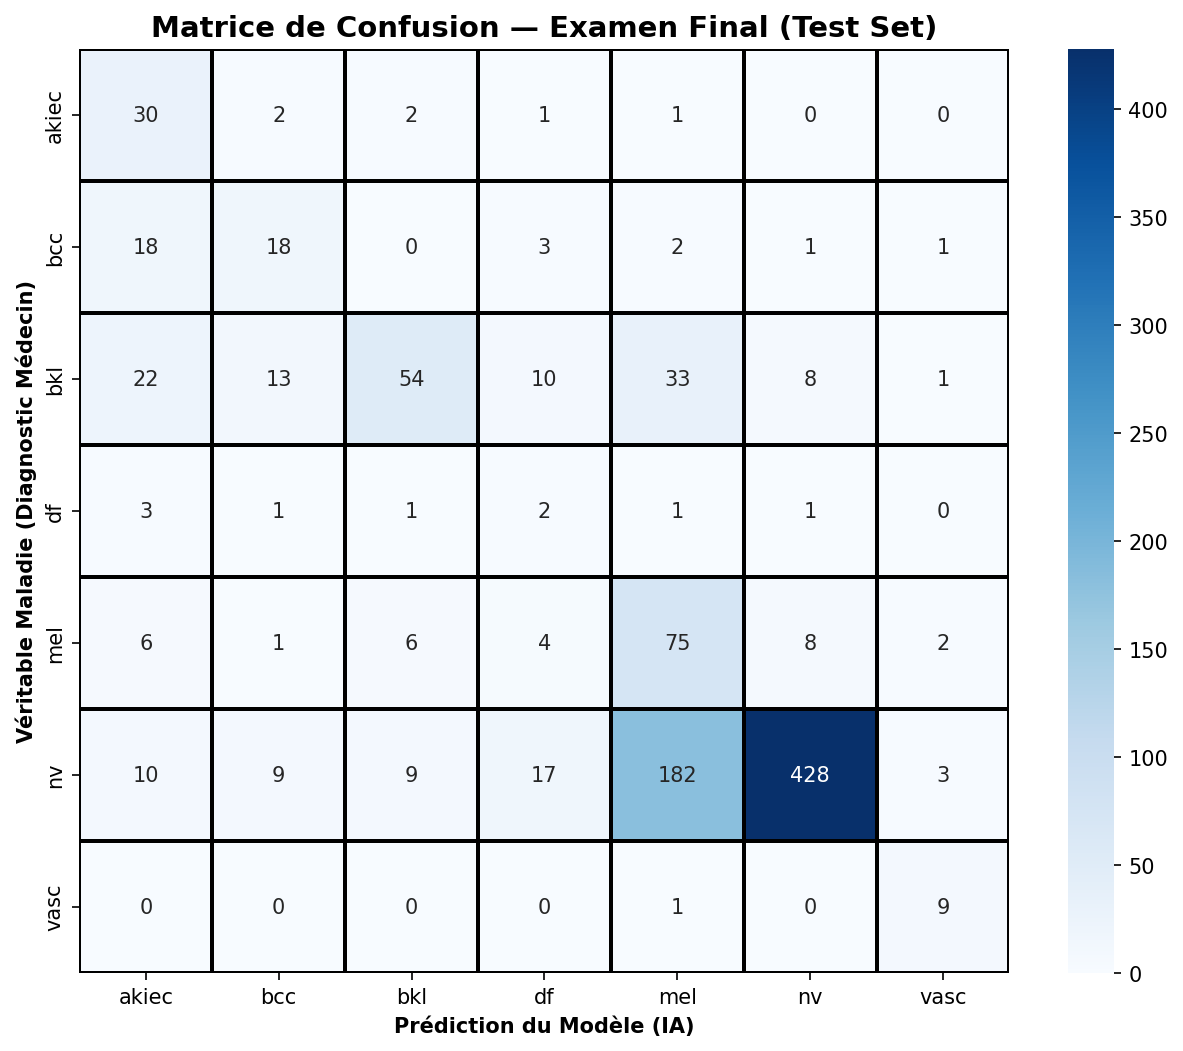


==================================================
RAPPORT DE CLASSIFICATION OFFICIEL
==================================================
              precision    recall  f1-score   support

       akiec       0.34      0.83      0.48        36
         bcc       0.41      0.42      0.41        43
         bkl       0.75      0.38      0.51       141
          df       0.05      0.22      0.09         9
         mel       0.25      0.74      0.38       102
          nv       0.96      0.65      0.78       658
        vasc       0.56      0.90      0.69        10

    accuracy                           0.62       999
   macro avg       0.48      0.59      0.48       999
weighted avg       0.80      0.62      0.66       999


# Interprétation des Résultats — Modèle de Classification Dermatologique

---

## Vue d'ensemble

Le modèle atteint une accuracy globale de **62%** sur 999 échantillons de test, ce qui peut sembler modeste à première vue, mais ce chiffre mérite d'être nuancé. Le dataset est fortement déséquilibré — la classe *nv* (nævi mélanocytaires) représente à elle seule 658 des 999 cas, soit **65,9% du test set**. Dans ce contexte, une accuracy de 62% reflète surtout les difficultés du modèle sur les classes minoritaires, et non une défaillance générale.

---

## Analyse classe par classe

**nv — Nævi mélanocytaires (la classe dominante)**
C'est là que le modèle excelle le plus : precision de 0.96, ce qui signifie que quand il prédit *nv*, il a presque toujours raison. En revanche, le recall tombe à 0.65 — il "rate" environ un tiers des vrais cas de nv, les confondant massivement avec *mel* (182 cas mal classés). C'est la principale source de bruit dans la matrice. Le f1-score de 0.78 reste le meilleur de toutes les classes.

**vasc — Lésions vasculaires**
Malgré seulement 10 cas, le modèle s'en sort remarquablement bien : recall de 0.90, f1 de 0.69. 9 des 10 cas sont correctement identifiés. La classe est probablement visuellement très distincte des autres, ce qui facilite la tâche.

**mel — Mélanome**
Classe critique sur le plan clinique. Le recall de 0.74 est acceptable (75 vrais mélanomes détectés sur 102), mais la precision de seulement 0.25 est problématique : le modèle génère énormément de faux positifs, notamment en "recyclant" des cas nv comme mélanomes. Dans un contexte médical réel, cette tendance à sur-détecter le mélanome aurait un coût humain et organisationnel non négligeable, même si elle est préférable à l'inverse.

**akiec — Carcinome épidermoïde in situ**
Le recall de 0.83 est surprenant pour une classe de seulement 36 cas — le modèle identifie bien les vrais *akiec*. Mais avec une precision de 0.34, deux tiers des prédictions *akiec* sont des erreurs. La matrice montre que les confusions proviennent surtout de *bkl* (22 cas) et *mel* (6 cas).

**bkl — Kératose bénigne**
Classe avec le plus grand nombre de confusions dispersées. Sur 141 cas, seulement 54 sont correctement classés (recall de 0.38). Les erreurs sont éparpillées vers *akiec*, *bcc*, *mel* et *nv* — ce qui suggère que *bkl* est une classe visuellement hétérogène, difficile à cerner pour le modèle. La precision de 0.75, elle, est bonne : quand le modèle dit *bkl*, c'est souvent juste, mais il ne le dit pas assez souvent.

**bcc — Carcinome basocellulaire**
Performances médiocres et équilibrées dans le mauvais sens : precision 0.41, recall 0.42. Seulement 18 cas sur 43 correctement identifiés. La confusion principale est avec *akiec* (18 cas redirigés vers cette classe), ce qui est cliniquement compréhensible vu la similarité morphologique de ces deux types de lésions.

**df — Dermatofibrome**
La classe la plus problématique. 9 cas au total, 2 seulement bien classés. Le f1 de 0.09 est le pire du tableau. Avec un support aussi faible, le modèle n'a probablement pas vu suffisamment d'exemples pour apprendre une représentation fiable. Ce n'est pas tant un échec du modèle qu'un problème de données.

---

## Ce que dit la matrice au-delà des chiffres

La diagonale principale est hétérogène : forte pour *nv* (428) et *mel* (75), mais très faible pour *bkl* (54), *bcc* (18) et quasi inexistante pour *df* (2). La colonne *mel* et la colonne *nv* concentrent la majorité des prédictions — le modèle a une tendance structurelle à "attirer" les cas ambigus vers ces deux classes, probablement parce qu'elles sont les plus représentées à l'entraînement.

Un détail frappant : la ligne *nv* montre 182 cas prédits comme *mel*. Ce glissement nv→mel est le flux d'erreur le plus important de toute la matrice, et il a une double implication — il pénalise le recall de *nv* tout en gonflant artificiellement les faux positifs de *mel*.

---

## Bilan synthétique

| Axe | Constat |
|-----|---------|
| Points forts | Très bonne precision sur *nv*, bon recall sur *vasc* et *akiec* |
| Points faibles | *df* quasiment non appris, *bcc* et *bkl* sous-performants |
| Biais principal | Sur-représentation de *nv* dans les prédictions |
| Risque clinique | Faux positifs élevés sur *mel*, faux négatifs sur *bkl* |

Le weighted average (f1 = 0.66) est tiré vers le haut par *nv*, tandis que le macro average (f1 = 0.48) reflète plus fidèlement la performance réelle sur les classes rares. C'est ce dernier qui devrait guider les décisions d'amélioration : rééquilibrage des classes, augmentation de données sur *df*, *bcc* et *bkl*, ou l'utilisation de pondérations de classes à l'entraînement.

===

L'examen de la matrice de confusion et du rapport de classification révèle un modèle dont le comportement est cohérent avec les observations faites sur les courbes d'entraînement. L'accuracy globale de 62% ne doit pas être lue isolément : elle masque des disparités importantes entre les classes, directement imputables au déséquilibre du jeu de données. La classe nv, qui représente près des deux tiers des échantillons, monopolise l'attention du modèle — ce qui se traduit par une precision quasi parfaite de 0.96 sur cette classe, au détriment des classes minoritaires comme df ou bcc qui restent largement sous-apprises. Ce phénomène est typique d'un modèle qui optimise une loss globale sans mécanisme correctif, et qui converge naturellement vers les classes les plus fréquentes. Par ailleurs, le macro f1-score de 0.48, bien en dessous du weighted f1 de 0.66, confirme que les bonnes performances agrégées sont artificiellement gonflées par nv : sur les classes rares, le modèle peine réellement. La confusion structurelle entre mel et nv — avec 182 cas de nævi mal étiquetés comme mélanomes — illustre également les limites d'un réseau insuffisamment expressif pour capturer des frontières de décision fines dans un espace de features complexe. Ces résultats sont donc moins le signe d'un problème d'implémentation que celui d'un modèle qui a atteint son plafond de capacité, ce qui plaide pour une architecture plus profonde, un rééquilibrage des classes à l'entraînement, ou les deux à la fois.